In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [21]:
"""
Create a Linear Regression Model using Python/R to predict home prices using Boston Housing
Dataset (https://www.kaggle.com/c/boston-housing). The Boston Housing dataset contains
information about various houses in Boston through different parameters. There are 506 samples
and 14 feature variables in this dataset.
The objective is to predict the value of prices of the house using the given features
"""

'\nCreate a Linear Regression Model using Python/R to predict home prices using Boston Housing\nDataset (https://www.kaggle.com/c/boston-housing). The Boston Housing dataset contains\ninformation about various houses in Boston through different parameters. There are 506 samples\nand 14 feature variables in this dataset.\nThe objective is to predict the value of prices of the house using the given features\n'

In [22]:
from sklearn.datasets import make_regression

x, y = make_regression(n_samples = 506, n_features = 5, noise=20, random_state=42)
features = ['crime', 'age', 'ptratio', 'area', 'school_proximity']

df = pd.DataFrame(x, columns = features)
df['cost'] = y
df.head()

,crime,age,ptratio,area,school_proximity,cost
0,0.421587,-0.617253,0.838941,-1.100154,-0.558302,29.823821
1,-0.280675,-0.098340,-1.692957,-1.103589,-0.988591,-212.755009
2,1.441273,1.163164,-1.435862,-0.981509,0.010233,-67.913647
3,0.106430,1.503993,-0.254977,1.091507,-2.650970,-135.055735
4,1.732515,0.638051,2.231300,-1.801058,0.500844,197.792650


In [23]:
df.columns

Index(['crime', 'age', 'ptratio', 'area', 'school_proximity', 'cost'], dtype='str')

In [24]:
df.shape

(506, 6)

In [25]:
#medv -> median house price (target value)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   crime             506 non-null    float64
 1   age               506 non-null    float64
 2   ptratio           506 non-null    float64
 3   area              506 non-null    float64
 4   school_proximity  506 non-null    float64
 5   cost              506 non-null    float64
dtypes: float64(6)
memory usage: 23.8 KB


In [26]:
#Split independent and dependent variables
X = df.drop('cost', axis = 1)
Y = df['cost']

In [27]:
#Split the dataset into train and test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42
)

In [28]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred = model.predict(X_test)

In [30]:
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("MSE: ", mse) #lower the better
print("R2: ", r2) #close to 1 is better

MSE:  328.5409389818814
R2:  0.9602790819806494


In [31]:
#Compare actual and predicted
results = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': y_pred
})

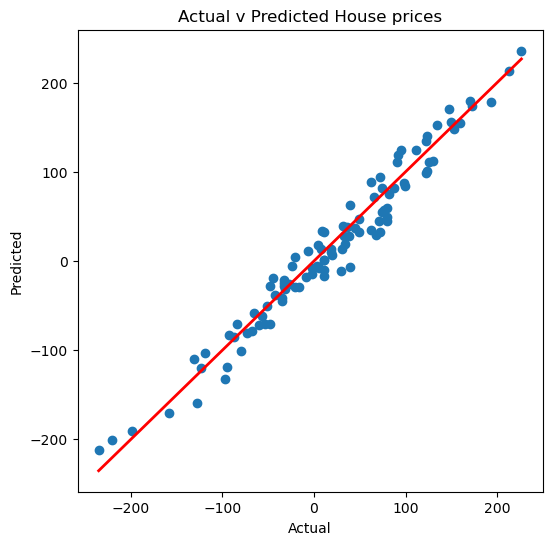

In [33]:
#Scatter PLot
plt.figure(figsize=(6,6))
plt.scatter(Y_test, y_pred)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    linewidth=2, color="red"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual v Predicted House prices")
plt.show()